# Dynamic Responsibility

This notebook demonstrates the dynamic responsibility framework introduced in the paper. We construct a directed interaction graph from the data, model exposure sequences for each user, and compute source-level responsibility over time. The core methodology is based on exact Shapley value computation under a noisy-or model, allowing responsibility to be attributed across multiple interacting sources. We track both:

- **instantaneous contributions** (time-indexed deltas), and
- **aggregate responsibility** per source.

The notebook is structured to:
1. Load and preprocess the data, and build the interaction graph  
2. Compute dynamic responsibility  
3. Analyse and visualise the resulting contributions  

All computations are exact (using rational arithmetic) and are intended to support reproducibility of the results presented in the paper.

### 1. Load data and build graph

This cell loads the dataset from `../data/data.csv`, verifies that the required columns are present, and applies basic type normalization to avoid inconsistencies. Identifier fields are cast to strings, and the `weight` column is converted to numeric values.

A directed multigraph is then constructed using NetworkX, where each row corresponds to an edge from `source` to `user`, with associated metadata (`tweet_id`, `timestamp`, `weight`) stored as edge attributes. The resulting graph preserves multiple interactions between the same nodes.

Finally, the total number of nodes and edges is reported.


In [1]:
import pandas as pd
import networkx as nx

# --- Load data ---
df_all = pd.read_csv("../data/data.csv")

# (Optional) ensure required columns exist
required = {"source", "user", "tweet_id", "timestamp", "weight"}
missing = required - set(df_all.columns)
if missing:
    raise ValueError(f"../data/data.csv is missing columns: {sorted(missing)}")

# (Optional) light normalisation to avoid dtype surprises
df_all["source"] = df_all["source"].astype(str)
df_all["user"] = df_all["user"].astype(str)
df_all["tweet_id"] = df_all["tweet_id"].astype(str)
# keep timestamp as-is (string/int); you can parse later if needed
df_all["weight"] = pd.to_numeric(df_all["weight"], errors="coerce").fillna(0.0)

# --- Build directed multigraph ---
G = nx.MultiDiGraph()

for _, row in df_all.iterrows():
    G.add_edge(
        row["source"],
        row["user"],
        tweet_id=row["tweet_id"],
        timestamp=row["timestamp"],
        weight=float(row["weight"]),
    )

print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")


Graph has 119322 nodes and 180303 edges.


### 2. Exact Shapley-based responsibility computation

This cell defines and executes the core responsibility computation. At its core is an exact implementation of the Shapley value for the noisy-or model, computed using rational arithmetic (`mpq`) to avoid numerical error. The algorithm runs in $(O(n^2))$ time and $(O(n))$ space for a single game.

The `ResponsibilityComputer` processes the interaction graph on a per-user basis. For each user, events are sorted temporally and the Shapley value is recomputed for each prefix of exposures. This yields a sequence of marginal contributions (“deltas”) over time, capturing how responsibility evolves as new exposures occur.

For each prefix:
- the Shapley vector is computed exactly,
- contributions are aggregated per source,
- differences from the previous prefix are recorded as time-indexed deltas.

Final per-source responsibility (`c_resp`) is obtained by summing the last-prefix contributions across all users.

This implementation is exact but computationally expensive, with $O(L^3)$ time per user for $L$ exposures due to repeated prefix recomputation.

In [4]:
import os, sys
from pathlib import Path
import math
import time
from dataclasses import dataclass
from collections import defaultdict
from typing import Any, Dict, Iterable, List, Optional, Tuple

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from gmpy2 import mpq
from tqdm import tqdm

# Add project root (notebook is in ./notebooks; src is a sibling directory)
sys.path.insert(0, str(Path().resolve().parents[0]))

from src.shapley_noisy_OR import (  # noqa: E402
    brute_force_shapley_all_mpq,
    noisy_or_shapley_float64,
    noisy_or_shapley_mpq,
)

# =========================================================
# Core computation (no plotting)
# =========================================================
@dataclass(frozen=True)
class ResponsibilityResult:
    """
    Core output:
      - deltas: long table [timestamp, source, delta] (delta is float)
      - c_resp: dict[source] -> final total responsibility (float)
    """
    deltas: pd.DataFrame
    c_resp: Dict[Any, float]


class ResponsibilityComputer:
    """
    Computes dynamic responsibilities from a MultiDiGraph exposure model.

    This version computes Shapley for each prefix m by calling
    noisy_or_shapley_mpq(weights[:m]) exactly. This is simple and exact,
    but is O(L^3) per user in the number of exposures L (since it sums O(m^2)
    work over m=1..L).
    """

    def __init__(
        self,
        G: nx.MultiDiGraph,
        max_edges: Optional[int] = 1000,
        dump_deltas_path: Optional[str] = None,
        chunk_size: int = 200_000,
    ):
        self.G = G
        self.max_edges = None if max_edges is None else int(max_edges)
        self.dump_deltas_path = dump_deltas_path
        self.chunk_size = int(chunk_size)

    def _iter_limited_edges(self) -> Iterable[Tuple[Any, Any, Any, Dict[str, Any]]]:
        try:
            it = self.G.edges(keys=True, data=True)
            for i, (u, v, k, d) in enumerate(it):
                if self.max_edges is not None and i >= self.max_edges:
                    break
                yield (u, v, k, d)
        except TypeError:
            it = self.G.edges(data=True)
            for i, (u, v, d) in enumerate(it):
                if self.max_edges is not None and i >= self.max_edges:
                    break
                yield (u, v, None, d)

    @staticmethod
    def _parse_weight_mpq(value: Any) -> mpq:
        try:
            w = mpq(str(value))
        except Exception:
            return mpq(0)
        if w < 0:
            return mpq(0)
        if w > 1:
            return mpq(1)
        return w

    def compute_deltas_and_totals(self, log_every_sec: int = 20) -> ResponsibilityResult:
        # Build per-user event lists using ONLY the first max_edges edges
        edges_by_user: Dict[Any, List[Tuple[Any, Dict[str, Any]]]] = defaultdict(list)
        for src, user, _, d in self._iter_limited_edges():
            edges_by_user[user].append((src, d))

        c_resp_totals: Dict[Any, float] = defaultdict(float)

        use_dump = self.dump_deltas_path is not None
        delta_records: List[Dict[str, Any]] = []
        delta_chunk: List[Dict[str, Any]] = []

        if use_dump:
            os.makedirs(os.path.dirname(self.dump_deltas_path) or ".", exist_ok=True)

        start = time.time()
        last_log = start

        for user, edge_list in tqdm(edges_by_user.items(), desc="Users (exact prefix Shapley → deltas)"):
            events: List[Tuple[Any, pd.Timestamp, mpq]] = []

            for src, d in edge_list:
                ts = pd.to_datetime(d.get("timestamp"), utc=True, errors="coerce")
                if pd.isna(ts):
                    continue

                w_mpq = self._parse_weight_mpq(d.get("weight", 0.0))
                if w_mpq == 0:
                    continue

                events.append((src, ts, w_mpq))

            if not events:
                continue

            # Sort by time
            events.sort(key=lambda x: x[1])
            sources = [e[0] for e in events]
            times = [e[1] for e in events]
            weights = [e[2] for e in events]
            L = len(weights)

            # For each prefix m, compute exact Shapley vector on weights[:m]
            prev_by_source: Dict[Any, mpq] = defaultdict(mpq)

            for m in range(1, L + 1):
                phi_m = noisy_or_shapley_mpq(weights[:m])  # exact

                # aggregate per-source for this prefix (exact mpq)
                cur_by_source: Dict[Any, mpq] = defaultdict(mpq)
                for i in range(m):
                    cur_by_source[sources[i]] += phi_m[i]

                # emit deltas at time times[m-1]
                t_m = times[m - 1]

                # Only iterate keys that exist (exact; missing keys are 0)
                keys = set(prev_by_source.keys())
                keys.update(cur_by_source.keys())

                for s in keys:
                    delta = cur_by_source.get(s, mpq(0)) - prev_by_source.get(s, mpq(0))
                    if delta == 0:
                        continue

                    rec = {"timestamp": t_m, "source": s, "delta": float(delta)}

                    if use_dump:
                        delta_chunk.append(rec)
                        if len(delta_chunk) >= self.chunk_size:
                            pd.DataFrame(delta_chunk).to_parquet(
                                self.dump_deltas_path,
                                engine="pyarrow",
                                compression="snappy",
                                append=True,
                            )
                            delta_chunk.clear()
                    else:
                        delta_records.append(rec)

                prev_by_source = cur_by_source

            # final prefix = C_resp contribution for this user
            for s, val in prev_by_source.items():
                c_resp_totals[s] += float(val)

            now = time.time()
            if now - last_log >= log_every_sec:
                elapsed = now - start
                stored = "streaming" if use_dump else str(len(delta_records))
                print(
                    f"[{elapsed:6.1f}s] users={len(edges_by_user):,} "
                    f"deltas={stored} sources={len(c_resp_totals):,}"
                )
                last_log = now

        if use_dump and delta_chunk:
            pd.DataFrame(delta_chunk).to_parquet(
                self.dump_deltas_path,
                engine="pyarrow",
                compression="snappy",
                append=True,
            )

        if use_dump:
            deltas_df = pd.read_parquet(self.dump_deltas_path, engine="pyarrow")
        else:
            deltas_df = pd.DataFrame(delta_records)

        if not deltas_df.empty:
            deltas_df = deltas_df.dropna(subset=["timestamp"]).sort_values("timestamp")
        else:
            deltas_df = pd.DataFrame(columns=["timestamp", "source", "delta"])

        return ResponsibilityResult(deltas=deltas_df, c_resp=dict(c_resp_totals))


# =========================================================
# Example usage
# =========================================================
computer = ResponsibilityComputer(G, max_edges=None, dump_deltas_path=None)
result = computer.compute_deltas_and_totals(log_every_sec=20)


Users (exact prefix Shapley → deltas):   1%|▎                                  | 1075/118987 [00:30<5:08:27,  6.37it/s]

[  30.7s] users=118,987 deltas=17757 sources=333


Users (exact prefix Shapley → deltas):   5%|█▊                                   | 5794/118987 [01:01<59:39, 31.62it/s]

[  61.3s] users=118,987 deltas=62041 sources=518


Users (exact prefix Shapley → deltas):   8%|██▋                                 | 8955/118987 [01:21<04:24, 416.09it/s]

...

Users (exact prefix Shapley → deltas):  61%|████████████████████▋             | 72208/118987 [02:41<00:33, 1396.02it/s]

[ 161.3s] users=118,987 deltas=278550 sources=714


Users (exact prefix Shapley → deltas):  81%|███████████████████████████▌      | 96676/118987 [03:01<00:18, 1208.75it/s]

[ 181.3s] users=118,987 deltas=310600 sources=734


Users (exact prefix Shapley → deltas): 100%|██████████████████████████████████| 118987/118987 [03:18<00:00, 599.49it/s]


## 3. Visualisations

This cell generates the paper figures from the already-computed dynamic responsibility output stored in `result`, without recomputing any responsibility values.

It produces two stacked area plots:

1. **Absolute cumulative responsibility over time**, saved as `responsibility_absolute.png`
2. **Responsibility share over time**, saved as `responsibility_percentage_to_date.png`

The plotting setup is designed for paper-ready visualisation:

- no titles
- muted academic pastel colours
- a shared stack/legend definition across both plots
- `Others` plus all sources with at least 1% of final overall responsibility
- optional truncation to the first `K` timestamps for faster iteration
- optional temporal resampling via `FREQ`
- fixed y-range `[0.60, 1.00]` for the percentage plot

The cell assumes that the compute cell has already been run and that `result` exists, with:

- `result.deltas`: timestamped source-level responsibility increments
- `result.c_resp`: final source-level responsibility totals

The output figures are saved as PNG files and also displayed inline.


Build matrix: 100%|██████████████████████████████████████████████████████████████████| 772/772 [00:21<00:00, 35.35it/s]
C:\Users\dl1\AppData\Local\Temp\ipykernel_3988\374321138.py:98: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  R = pd.concat(series_list, axis=1).sort_index()


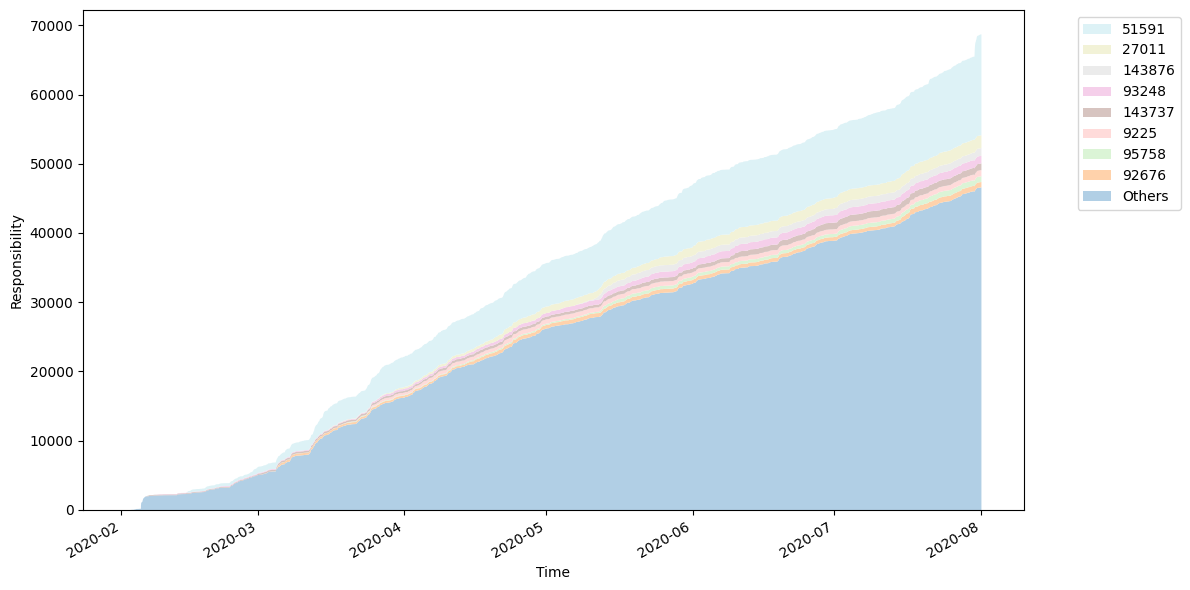

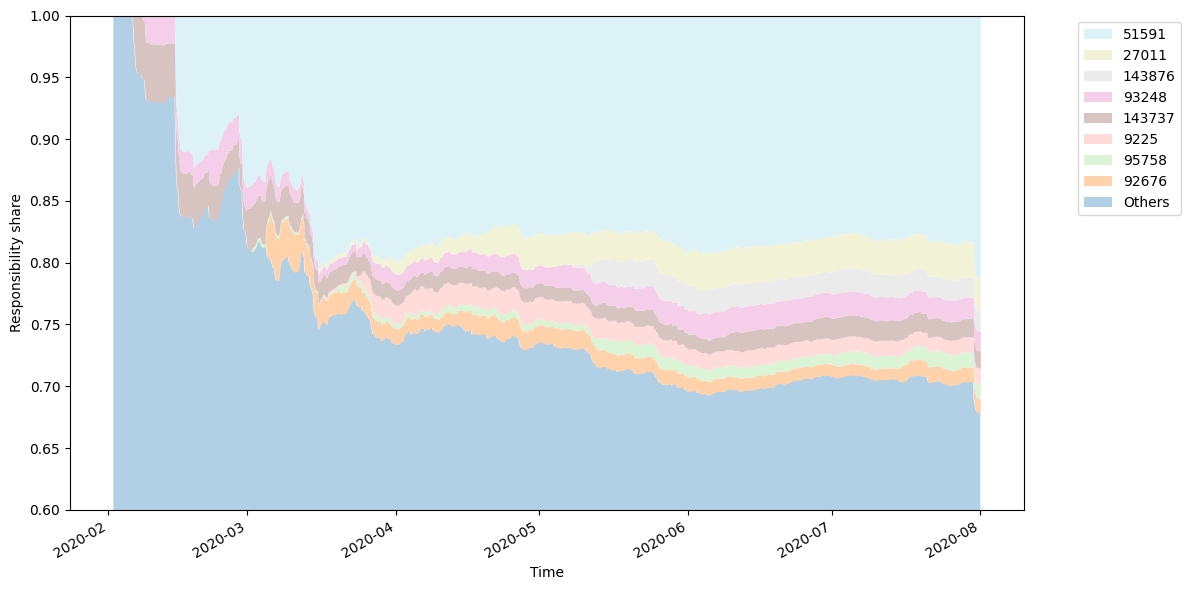

Saved:
  responsibility_absolute.png
  responsibility_percentage_to_date.png
Max |row_sum - 1| in % plot: 4.330e-15


In [5]:
# =========================================================
# FAST VISUALISATION CELL (no recomputation of responsibility)
# - Academic pastel colours 
# - No titles
# - Save PNGs
# - Legend = {"Others"} ∪ {sources with >=1% OVERALL (final totals)}
# - Same stacks/legend for BOTH plots
# - Toggle: ALL timestamps or first K timestamps (for speed)
# - Single progress bar
# - % plot: y-limits fixed to [0.60, 1.00]
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# -----------------------------
# USER TOGGLES
# -----------------------------
USE_ALL_TIMESTAMPS = True     # True = full plot (can be slow)
K_TIMESTAMPS = 10000          # used only if USE_ALL_TIMESTAMPS=False
THRESHOLD = 0.01              # 1%
FREQ = None                   # e.g. "1H" to resample; keep None for exact
PNG_ABS = "responsibility_absolute.png"
PNG_PCT = "responsibility_percentage_to_date.png"
FIGSIZE = (12, 6)
DPI = 200

# Pastel "tone" toggle: higher = more muted (toward white, not grey)
PASTEL_TONE = 0.65            # 0.4 vivid | 0.6 normal | 0.8 very soft

# % plot y-range (keep 60%+)
PCT_Y_MIN = 0.60
PCT_Y_MAX = 1.00


# -----------------------------
# Helpers
# -----------------------------
def _select_and_truncate_deltas(deltas_df: pd.DataFrame, use_all: bool, k: int) -> pd.DataFrame:
    df = deltas_df[["timestamp", "source", "delta"]].copy()
    df = df.dropna(subset=["timestamp"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
    df = df.dropna(subset=["timestamp"])
    df = df.sort_values("timestamp")

    if use_all:
        return df

    uniq = df["timestamp"].unique()
    if len(uniq) == 0:
        return df

    keep = uniq[: min(k, len(uniq))]
    return df[df["timestamp"].isin(keep)]


def build_responsibility_matrix_fast(
    deltas_df: pd.DataFrame,
    chosen_sources: list,
    freq: str | None = None,
    show_progress: bool = True,
) -> pd.DataFrame:
    """
    Build wide cumulative responsibility matrix R:
      - index: timestamp
      - columns: chosen_sources
      - values: cumulative responsibility up to that time
    """
    if deltas_df is None or deltas_df.empty or not chosen_sources:
        return pd.DataFrame()

    iterator = chosen_sources
    if show_progress:
        iterator = tqdm(chosen_sources, desc="Build matrix", total=len(chosen_sources))

    series_list = []
    for s in iterator:
        d = deltas_df.loc[deltas_df["source"] == s, ["timestamp", "delta"]]
        if d.empty:
            continue

        ser = d.set_index("timestamp")["delta"].sort_index()

        if freq is not None:
            ser = ser.resample(freq).sum()
        else:
            ser = ser.groupby(level=0).sum()

        ser = ser.cumsum()
        ser.name = s
        series_list.append(ser)

    if not series_list:
        return pd.DataFrame()

    R = pd.concat(series_list, axis=1).sort_index()
    R = R.ffill().fillna(0.0)
    return R.copy()  # de-fragment


def collapse_to_fixed_others(R: pd.DataFrame, kept_sources: list) -> pd.DataFrame:
    """
    Force the SAME column set across plots:
      - columns = ["Others"] + kept_sources
      - 'Others' = sum of all non-kept sources at each time
      - ordering: Others bottom; remaining ordered so largest ends up on top
        (ascending by final value).
    """
    if R.empty:
        return R

    kept_sources = [s for s in kept_sources if s in R.columns]
    drop_cols = [c for c in R.columns if c not in kept_sources]

    others = R[drop_cols].sum(axis=1) if drop_cols else pd.Series(0.0, index=R.index)
    out = pd.concat([others.rename("Others"), R[kept_sources]], axis=1)

    cols = [c for c in out.columns if c != "Others"]
    cols_sorted = list(out.iloc[-1][cols].sort_values(ascending=True).index)
    return out[["Others"] + cols_sorted]


def make_pastel_academic(n: int, tone: float = 0.65):
    """
    Academic-ish muted pastels derived from tab20 (varied hues) pulled toward white.
    tone = 0.0 -> base colours
    tone ~0.6  -> pastel
    tone ~0.8  -> very soft
    """
    base = plt.cm.tab20(np.linspace(0, 1, n))
    colors = []
    for r, g, b, _ in base:
        r = r + tone * (1 - r)
        g = g + tone * (1 - g)
        b = b + tone * (1 - b)
        colors.append((r, g, b))
    return colors


def plot_area_save(
    df: pd.DataFrame,
    ylabel: str,
    out_png: str,
    pastel_tone: float = 0.65,
    y_min: float | None = None,
    y_max: float | None = None,
) -> None:
    if df is None or df.empty:
        raise ValueError("Nothing to plot (empty DataFrame).")

    n = df.shape[1]
    colors = make_pastel_academic(n, tone=pastel_tone)

    fig, ax = plt.subplots(figsize=FIGSIZE)
    df.plot.area(ax=ax, linewidth=0, color=colors)

    ax.set_title("")
    ax.set_xlabel("Time")
    ax.set_ylabel(ylabel)

    if y_min is not None or y_max is not None:
        ax.set_ylim(y_min if y_min is not None else ax.get_ylim()[0],
                    y_max if y_max is not None else ax.get_ylim()[1])

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], title="", bbox_to_anchor=(1.05, 1), loc="upper left")


    fig.tight_layout()
    fig.savefig(out_png, dpi=DPI, bbox_inches="tight")
    plt.show()


# =========================================================
# Main (uses existing `result`)
# =========================================================
assert "result" in globals(), "Run the compute cell first so `result` exists."

# 1) Truncate deltas for quick test (optional)
df_deltas = _select_and_truncate_deltas(
    deltas_df=result.deltas,
    use_all=USE_ALL_TIMESTAMPS,
    k=K_TIMESTAMPS,
)

# 2) Decide legend/stacks: sources with >=1% overall responsibility (final totals from full run)
total_final = float(sum(result.c_resp.values()))
denom = total_final if total_final > 0 else 1.0

kept_sources = [
    s for s, v in result.c_resp.items()
    if (float(v) / denom) >= THRESHOLD
]
kept_sources = sorted(kept_sources, key=lambda s: float(result.c_resp[s]), reverse=True)

# 3) Build matrix only over sources present in the (possibly truncated) slice
sources_in_slice = df_deltas["source"].astype(str).unique().tolist()

R_slice = build_responsibility_matrix_fast(
    deltas_df=df_deltas,
    chosen_sources=sources_in_slice,
    freq=FREQ,
    show_progress=True,
)

R_abs = collapse_to_fixed_others(R_slice, kept_sources=kept_sources)

# 4) Plot 1: absolute cumulative responsibility
plot_area_save(
    df=R_abs,
    ylabel="Responsibility",
    out_png=PNG_ABS,
    pastel_tone=PASTEL_TONE,
)

# 5) Plot 2: percentage-to-date with SAME stacks as Plot 1 + y-limit to keep 60%+
row_sums = R_slice.sum(axis=1).replace(0.0, np.nan)
P_slice = R_slice.div(row_sums, axis=0).fillna(0.0)

P_fixed = collapse_to_fixed_others(P_slice, kept_sources=kept_sources)

plot_area_save(
    df=P_fixed,
    ylabel="Responsibility share",
    out_png=PNG_PCT,
    pastel_tone=PASTEL_TONE,
    y_min=PCT_Y_MIN,
    y_max=PCT_Y_MAX,
)

# ---- sanity check ----
row_err = float((P_fixed.sum(axis=1) - 1.0).abs().max())
print(f"Saved:\n  {PNG_ABS}\n  {PNG_PCT}")
print(f"Max |row_sum - 1| in % plot: {row_err:.3e}")